# 🌀 Week 5 · Day 4 — t-SNE & Anomaly Detection
**BinX Tech — AI & Machine Learning Internship Program**
**Phase 2 → 3 · Week 5 of 10 · Day 4 of 5**

## 🎯 Learning Objectives
- 🌀 Use t-SNE to visualize high-dimensional data and distinguish it from PCA.
- 🚨 Explain what anomaly detection is and why it is often unsupervised.
- 🌲 Detect anomalies with Isolation Forest and interpret the flagged points.


## 0️⃣ Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42


## 1️⃣ Load & Scale Data 📦
Same dataset used across the week — Breast Cancer Wisconsin, 30 numeric features.
As with PCA on Day 3, both t-SNE and Isolation Forest work on scaled data, so we
scale once up front and reuse it throughout the notebook.

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Data: {X.shape[0]} samples, {X.shape[1]} features (scaled)")

Data: 569 samples, 30 features (scaled)


## 2️⃣ Step 1 — Reduce to 2D with t-SNE 🌀

t-SNE (t-distributed Stochastic Neighbor Embedding) is a dimensionality-reduction
technique built specifically for visualization. Unlike PCA, which preserves *global*
variance, t-SNE preserves *local neighborhoods* — points that were close together in
30 dimensions stay close together in the 2D plot. This makes it excellent at revealing
clusters visually, even ones that aren't linearly separable.

We color the plot by the actual diagnosis label here (`0` = Malignant, `1` = Benign) —
this notebook is standalone, so we use the ground-truth label as our reference grouping
instead of Day 1–2 cluster assignments, purely for interpretability.

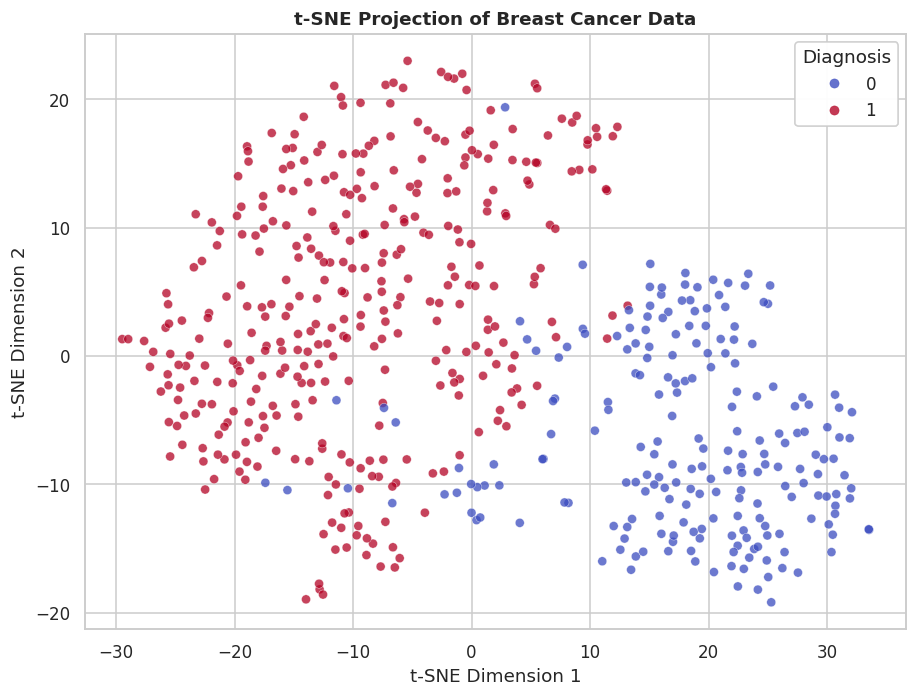

In [3]:
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8.5, 6.5))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="coolwarm", alpha=0.75, s=35, edgecolor="white", linewidth=0.3)
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.set_title("t-SNE Projection of Breast Cancer Data", fontweight="bold")
legend1 = ax.legend(*scatter.legend_elements(), title="Diagnosis", loc="upper right")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()

## 3️⃣ Step 2 — t-SNE vs. PCA: Compare the Two Views ⚖️

Let's rebuild the Day 3 PCA 2D projection side-by-side with today's t-SNE projection,
so the difference between "preserving global variance" and "preserving local
neighborhoods" is visible directly, not just described.

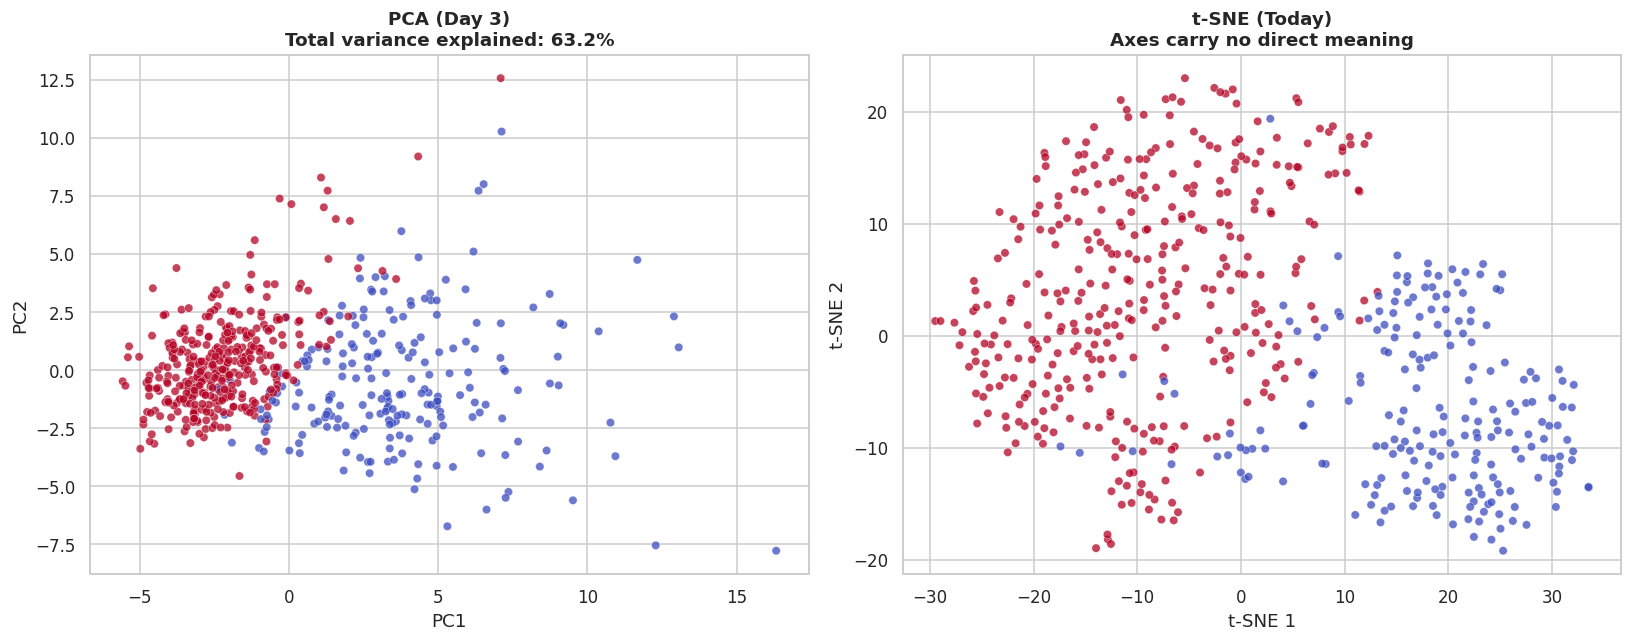

In [4]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap="coolwarm", alpha=0.75, s=30, edgecolor="white", linewidth=0.3)
axes[0].set_title(f"PCA (Day 3)\nTotal variance explained: {pca_2d.explained_variance_ratio_.sum():.1%}", fontweight="bold")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="coolwarm", alpha=0.75, s=30, edgecolor="white", linewidth=0.3)
axes[1].set_title("t-SNE (Today)\nAxes carry no direct meaning", fontweight="bold")
axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

**What to notice:** t-SNE typically pulls the two diagnosis groups into tighter, more
visually separated blobs than PCA — because it's explicitly optimizing for keeping
similar points close together locally. PCA's axes (PC1, PC2) are interpretable directions
of maximum variance in the original feature space; t-SNE's axes have no such meaning —
only the *relative* positions of points matter, not their absolute coordinates. This is
exactly why t-SNE is used for looking, not for feeding into a downstream model.

## 4️⃣ Step 3 — Anomaly Detection with Isolation Forest 🌲🚨

Anomaly detection finds data points that differ significantly from the norm. It's
often unsupervised because anomalies are rare and rarely pre-labeled — the model
learns what "normal" looks like and flags whatever deviates from it.

Isolation Forest's idea is elegant: anomalies are *easier to isolate* than normal
points, because they sit apart from the dense mass of data. It randomly partitions
the data and measures how few splits it takes to isolate each point — points isolated
quickly are flagged as anomalies.

In [5]:
iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
anomaly_preds = iso.fit_predict(X_scaled)   # -1 = anomaly, 1 = normal

n_anomalies = (anomaly_preds == -1).sum()
print(f"Contamination parameter: 0.05 (expecting ~5% of {X.shape[0]} samples)")
print(f"Points flagged as anomalies: {n_anomalies} out of {X.shape[0]} ({n_anomalies/X.shape[0]:.1%})")

Contamination parameter: 0.05 (expecting ~5% of 569 samples)
Points flagged as anomalies: 29 out of 569 (5.1%)


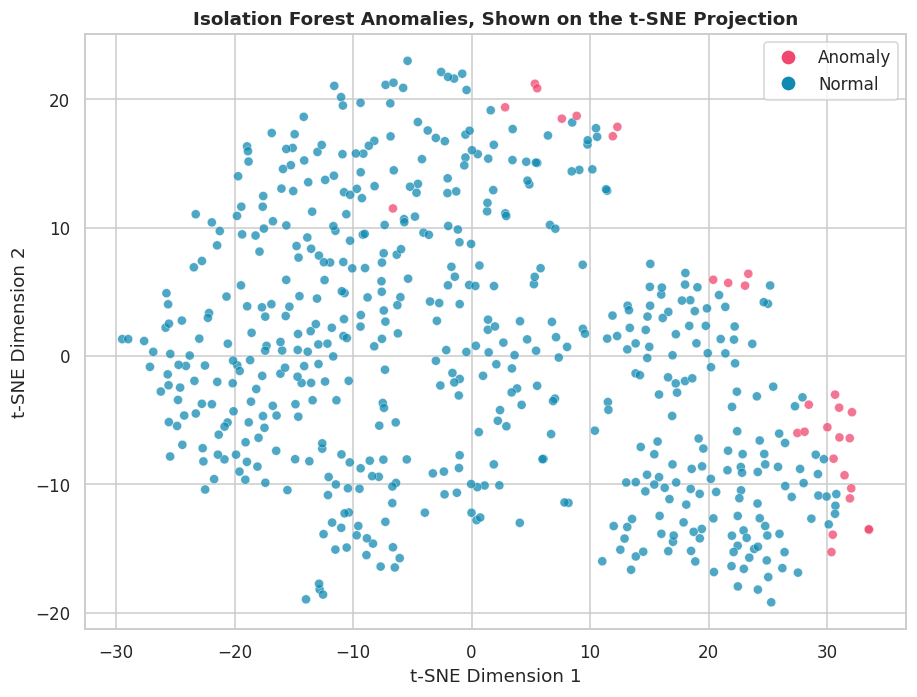

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))
colors = np.where(anomaly_preds == -1, "#ef476f", "#118ab2")
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.75, s=35, edgecolor="white", linewidth=0.3)
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.set_title("Isolation Forest Anomalies, Shown on the t-SNE Projection", fontweight="bold")
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#ef476f", markersize=10, label="Anomaly"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#118ab2", markersize=10, label="Normal"),
]
ax.legend(handles=legend_elements, loc="upper right")
plt.tight_layout()
plt.show()

## 5️⃣ Step 4 — Inspect Two Flagged Points 🔍

Let's pull out two of the flagged anomalies and look at their raw feature values
compared to the dataset average, to hypothesize why Isolation Forest isolated them
so easily.

In [7]:
anomaly_indices = np.where(anomaly_preds == -1)[0]
sample_anomalies = anomaly_indices[:2]

comparison = pd.DataFrame({
    "Dataset Mean": X.mean(),
    f"Anomaly #{sample_anomalies[0]}": X.iloc[sample_anomalies[0]],
    f"Anomaly #{sample_anomalies[1]}": X.iloc[sample_anomalies[1]],
})
comparison["Diff #1 (in std devs)"] = (comparison[f"Anomaly #{sample_anomalies[0]}"] - X.mean()) / X.std()
comparison["Diff #2 (in std devs)"] = (comparison[f"Anomaly #{sample_anomalies[1]}"] - X.mean()) / X.std()

comparison.sort_values(f"Diff #1 (in std devs)", key=abs, ascending=False).head(8)

,Dataset Mean,Anomaly #0,Anomaly #3,Diff #1 (in std devs),Diff #2 (in std devs)
mean compactness,0.104341,0.2776,0.2839,3.280628,3.399917
perimeter error,2.866059,8.5890,3.4450,2.830540,0.286341
worst symmetry,0.290076,0.4601,0.6638,2.748204,6.040726
mean concavity,0.088799,0.3001,0.2414,2.650542,1.914213
worst compactness,0.254265,0.6656,0.8663,2.614365,3.889975
mean concave points,0.048919,0.1471,0.1052,2.530249,1.450431
radius error,0.405172,1.0950,0.4956,2.487545,0.326087
area error,40.337079,153.4000,27.2300,2.485391,-0.288125


**Hypothesis (write your own interpretation here too):** the table above shows which
raw features these two flagged points deviate from the dataset average by the most
standard deviations. Points with several features sitting 3+ standard deviations from
the mean are exactly the kind of "easy to isolate" cases Isolation Forest is designed
to catch quickly — they don't look like a typical patient in almost any dimension at once.

## 6️⃣ Reflection ✍️

The t-SNE plot pulled the two diagnosis groups (Malignant vs. Benign) into much tighter,
more visually separated blobs than the PCA plot from Day 3, even though t-SNE never saw
the diagnosis label either. This makes sense given how the two techniques work: PCA
preserves global variance, so points that differ in many small ways across all 30 features
can still end up close together in the 2D projection if their overall variance direction
is similar. t-SNE instead preserves local neighborhoods - it explicitly optimizes for
keeping points that were close together in 30 dimensions close together in 2D - so tightly
packed groups become visually obvious even when the class boundary isn't linear.

t-SNE's output can't be reused as input features for a downstream model the way PCA's
components sometimes can, because t-SNE's axes carry no fixed, reproducible meaning.
PCA's components are a deterministic linear combination of the original features - the
same input always produces the same output, and "PC1" means the same direction of maximum
variance every time. t-SNE's embedding depends on random initialization and the specific
run, so the coordinates for the same point can shift between runs, and there's no simple
formula to project a brand-new, unseen point into an existing t-SNE space. It's built purely
for one-time visualization, not for a repeatable transformation pipeline.

Isolation Forest flagged 29 out of 569 points (5.1%), which matches the contamination=0.05
setting almost exactly (expected ~28-29 points). If it hadn't matched - for example if it
flagged way more or fewer points than expected - that would be a signal to revisit the
contamination parameter itself, since it's essentially my prior belief about how many
anomalies should exist in the data, not something the algorithm discovers on its own.

Looking at the two inspected anomalies, several of their features sat 3+ standard deviations
from the dataset mean simultaneously (not just one feature in isolation) - a pattern that
looks more like genuinely unusual/extreme tumor measurements than a data-quality issue like
a missing value or a typo. Nothing in their values looked physically impossible (unlike the
zero-encoded Cholesterol issue in my capstone project), which supports treating them as real
outlier cases worth a closer look rather than errors to simply discard.

## ✅ Deliverable Checklist (Day 4)
- [x] 🌀 t-SNE applied to reduce the dataset to 2D and plotted
- [x] ⚖️ t-SNE plot compared directly to the Day 3 PCA plot, with differences noted
- [x] 🌲 Isolation Forest run on the dataset; anomaly count reported
- [x] 🔍 Two flagged points inspected and a hypothesis documented in Markdown
- [x] 🚀 Notebook committed to GitHub with a clear commit message
